# Notebook 2: Baseline Attacks — FGSM and PGD

**Goal:** Implement and evaluate FGSM and PGD attacks. These are our baselines that the GA attack will be compared against.

**Output:** Attack success rates saved to `../results/tables/baseline_results.csv`

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../')

from src.model import CNN
from src.attacks import fgsm_attack, pgd_attack, evaluate_attack

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load trained model
model = CNN().to(device)
model.load_state_dict(torch.load('../results/model.pth', map_location=device))
model.eval()
print('Model loaded.')

Model loaded.


In [6]:
# Load test data (without normalization for visualization)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

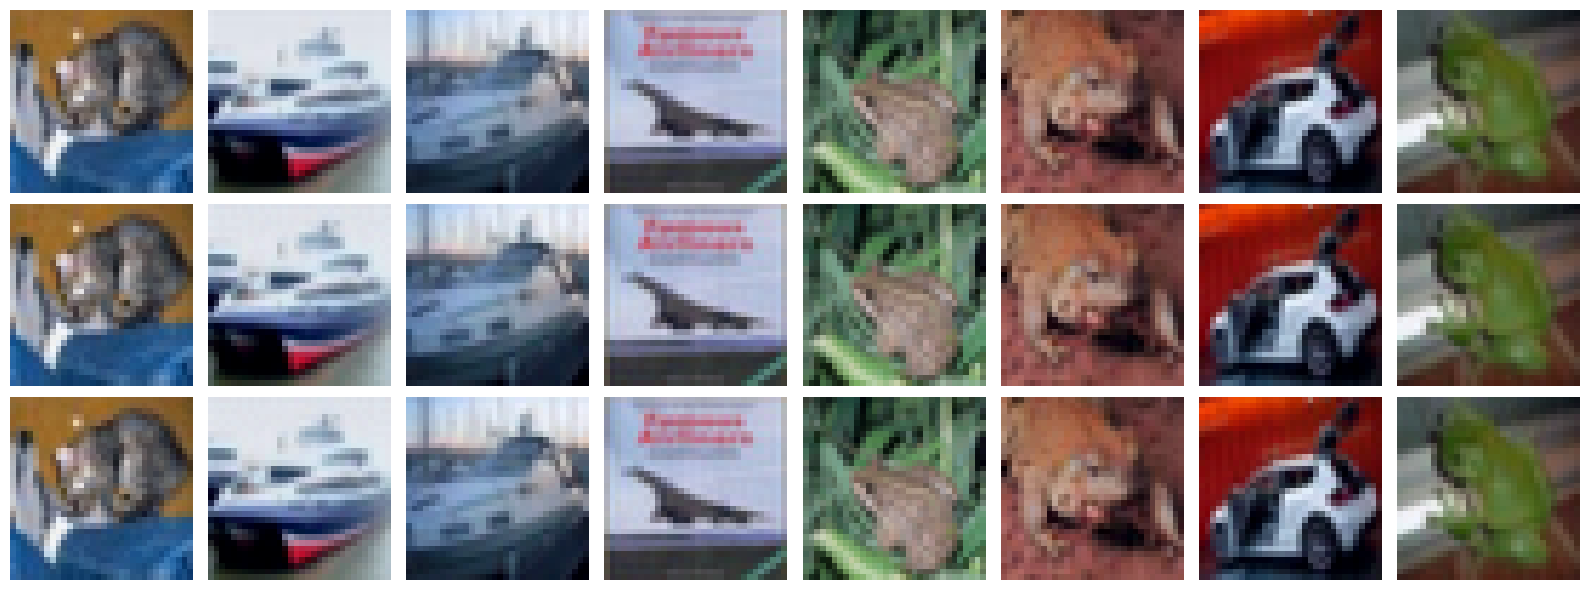

In [7]:
# Visualize adversarial examples
images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

fgsm_fn = lambda m, x, y: fgsm_attack(m, x, y, epsilon=0.03)
pgd_fn  = lambda m, x, y: pgd_attack(m, x, y, epsilon=0.03)

adv_fgsm = fgsm_fn(model, images, labels)
adv_pgd  = pgd_fn(model, images, labels)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
titles = ['Original', 'FGSM', 'PGD']
samples = [images, adv_fgsm, adv_pgd]

for row, (title, imgs) in enumerate(zip(titles, samples)):
    for col in range(8):
        img = imgs[col].cpu().detach().permute(1,2,0).numpy()
        img = (img * 0.2 + 0.45).clip(0,1)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(title, fontsize=12)

plt.tight_layout()
plt.savefig('../results/figures/adversarial_examples_baseline.png', dpi=150)
plt.show()

In [8]:
# Evaluate FGSM and PGD at different epsilon values
epsilons = [0.01, 0.03, 0.05, 0.1]
results = {'epsilon': epsilons, 'fgsm_asr': [], 'pgd_asr': []}

for eps in epsilons:
    fgsm_fn = lambda m, x, y: fgsm_attack(m, x, y, epsilon=eps)
    pgd_fn  = lambda m, x, y: pgd_attack(m, x, y, epsilon=eps)

    fgsm_res = evaluate_attack(model, testloader, fgsm_fn, device, max_samples=500)
    pgd_res  = evaluate_attack(model, testloader, pgd_fn, device, max_samples=500)

    results['fgsm_asr'].append(fgsm_res['attack_success_rate'])
    results['pgd_asr'].append(pgd_res['attack_success_rate'])

    print(f"eps={eps:.2f} | FGSM ASR: {fgsm_res['attack_success_rate']:.3f} | PGD ASR: {pgd_res['attack_success_rate']:.3f}")

eps=0.01 | FGSM ASR: 0.348 | PGD ASR: 0.375
eps=0.03 | FGSM ASR: 0.633 | PGD ASR: 0.779
eps=0.05 | FGSM ASR: 0.783 | PGD ASR: 0.973
eps=0.10 | FGSM ASR: 0.916 | PGD ASR: 1.000


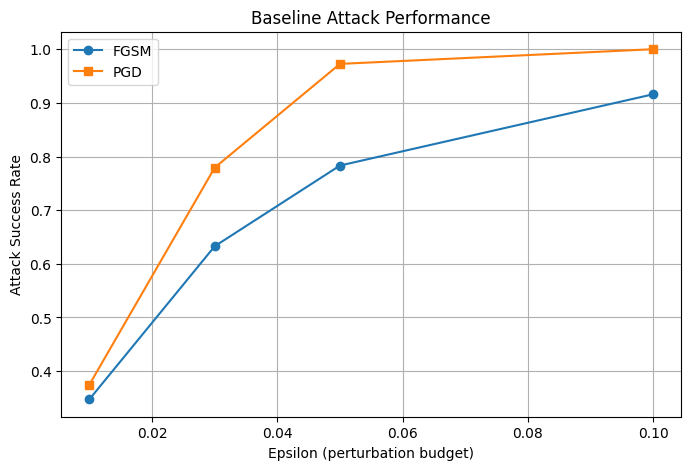

In [9]:
# Plot results
plt.figure(figsize=(8,5))
plt.plot(epsilons, results['fgsm_asr'], 'o-', label='FGSM')
plt.plot(epsilons, results['pgd_asr'],  's-', label='PGD')
plt.xlabel('Epsilon (perturbation budget)')
plt.ylabel('Attack Success Rate')
plt.title('Baseline Attack Performance')
plt.legend()
plt.grid(True)
plt.savefig('../results/figures/baseline_attack_comparison.png', dpi=150)
plt.show()

Playing with FGSM

[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


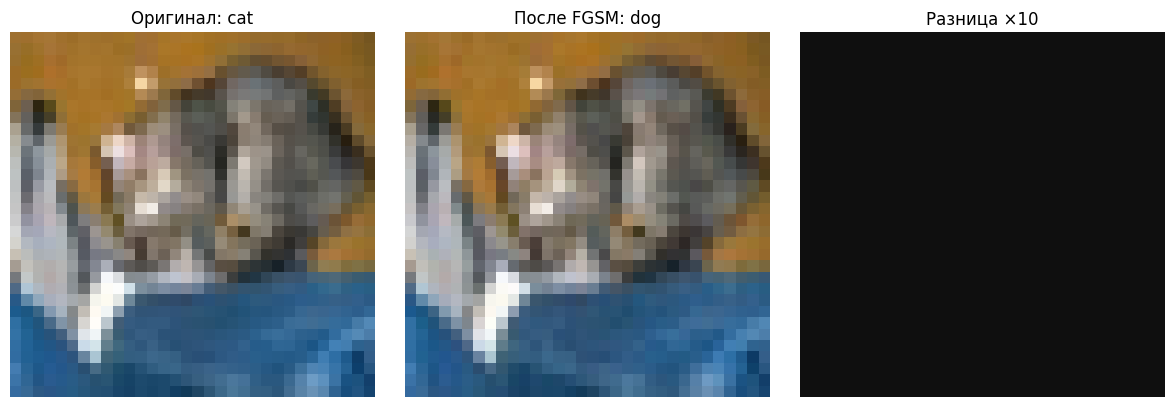

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../')

from src.model import CNN
from src.attacks import fgsm_attack

# Загрузка модели
device = torch.device('cpu')
model = CNN().to(device)
model.load_state_dict(torch.load('../results/model.pth', map_location=device))
model.eval()

# Загрузка одной картинки
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=False, transform=transform)
image, label = testset[0]  # первая картинка
image = image.unsqueeze(0).to(device)  # добавляем batch dimension
label_tensor = torch.tensor([label]).to(device)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

# Атака
adv_image = fgsm_attack(model, image, label_tensor, epsilon=0.03)

# Денормализация для отображения
def denorm(tensor):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    return (tensor.squeeze(0).cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy()

orig = denorm(image)
adv  = denorm(adv_image)
diff = np.abs(adv - orig)  # разница пикселей

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(orig)
axes[0].set_title(f'Оригинал: {classes[label]}')
axes[0].axis('off')

axes[1].imshow(adv)
pred = model(adv_image).argmax(dim=1).item()
axes[1].set_title(f'После FGSM: {classes[pred]}')
axes[1].axis('off')

# diff усилен ×10 чтобы было видно
axes[2].imshow((diff * 10).clip(0,1))
axes[2].set_title('Разница ×10')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [3]:
orig_flat = image.squeeze(0).detach().numpy().flatten()
adv_flat  = adv_image.squeeze(0).detach().numpy().flatten()
diff_flat = adv_flat - orig_flat

print(f"Всего пикселей (3×32×32): {len(diff_flat)}")
print(f"Изменённых пикселей:       {(diff_flat != 0).sum()}")
print(f"Макс. изменение:           {np.abs(diff_flat).max():.4f}")
print(f"Среднее изменение:         {np.abs(diff_flat).mean():.4f}")
print()
print("Первые 10 пикселей оригинала: ", orig_flat[:10].round(3))
print("Первые 10 пикселей после атаки:", adv_flat[:10].round(3))
print("Разница:                       ", diff_flat[:10].round(3))

Всего пикселей (3×32×32): 3072
Изменённых пикселей:       3072
Макс. изменение:           0.0300
Среднее изменение:         0.0300

Первые 10 пикселей оригинала:  [0.634 0.653 0.769 0.789 0.673 0.595 0.711 0.653 0.634 0.653]
Первые 10 пикселей после атаки: [0.604 0.623 0.739 0.759 0.643 0.565 0.741 0.623 0.604 0.683]
Разница:                        [-0.03 -0.03 -0.03 -0.03 -0.03 -0.03  0.03 -0.03 -0.03  0.03]


In [4]:
epsilons = [0.0, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2]

print(f"{'ε':<6} {'Предсказание':<12} {'Уверенность':>12}  {'Правильно?'}")
print("-" * 50)

for eps in epsilons:
    if eps == 0.0:
        img = image
    else:
        img = fgsm_attack(model, image, label_tensor, epsilon=eps)

    with torch.no_grad():
        logits = model(img)
        probs  = torch.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)

    correct = "✓" if pred.item() == label else "✗"
    print(f"{eps:<6} {classes[pred.item()]:<12} {conf.item()*100:>10.1f}%  {correct}")

ε      Предсказание  Уверенность  Правильно?
--------------------------------------------------
0.0    cat                81.9%  ✓
0.01   cat                59.7%  ✓
0.02   dog                57.7%  ✗
0.03   dog                69.1%  ✗
0.05   dog                82.7%  ✗
0.1    dog                93.5%  ✗
0.2    dog                91.7%  ✗


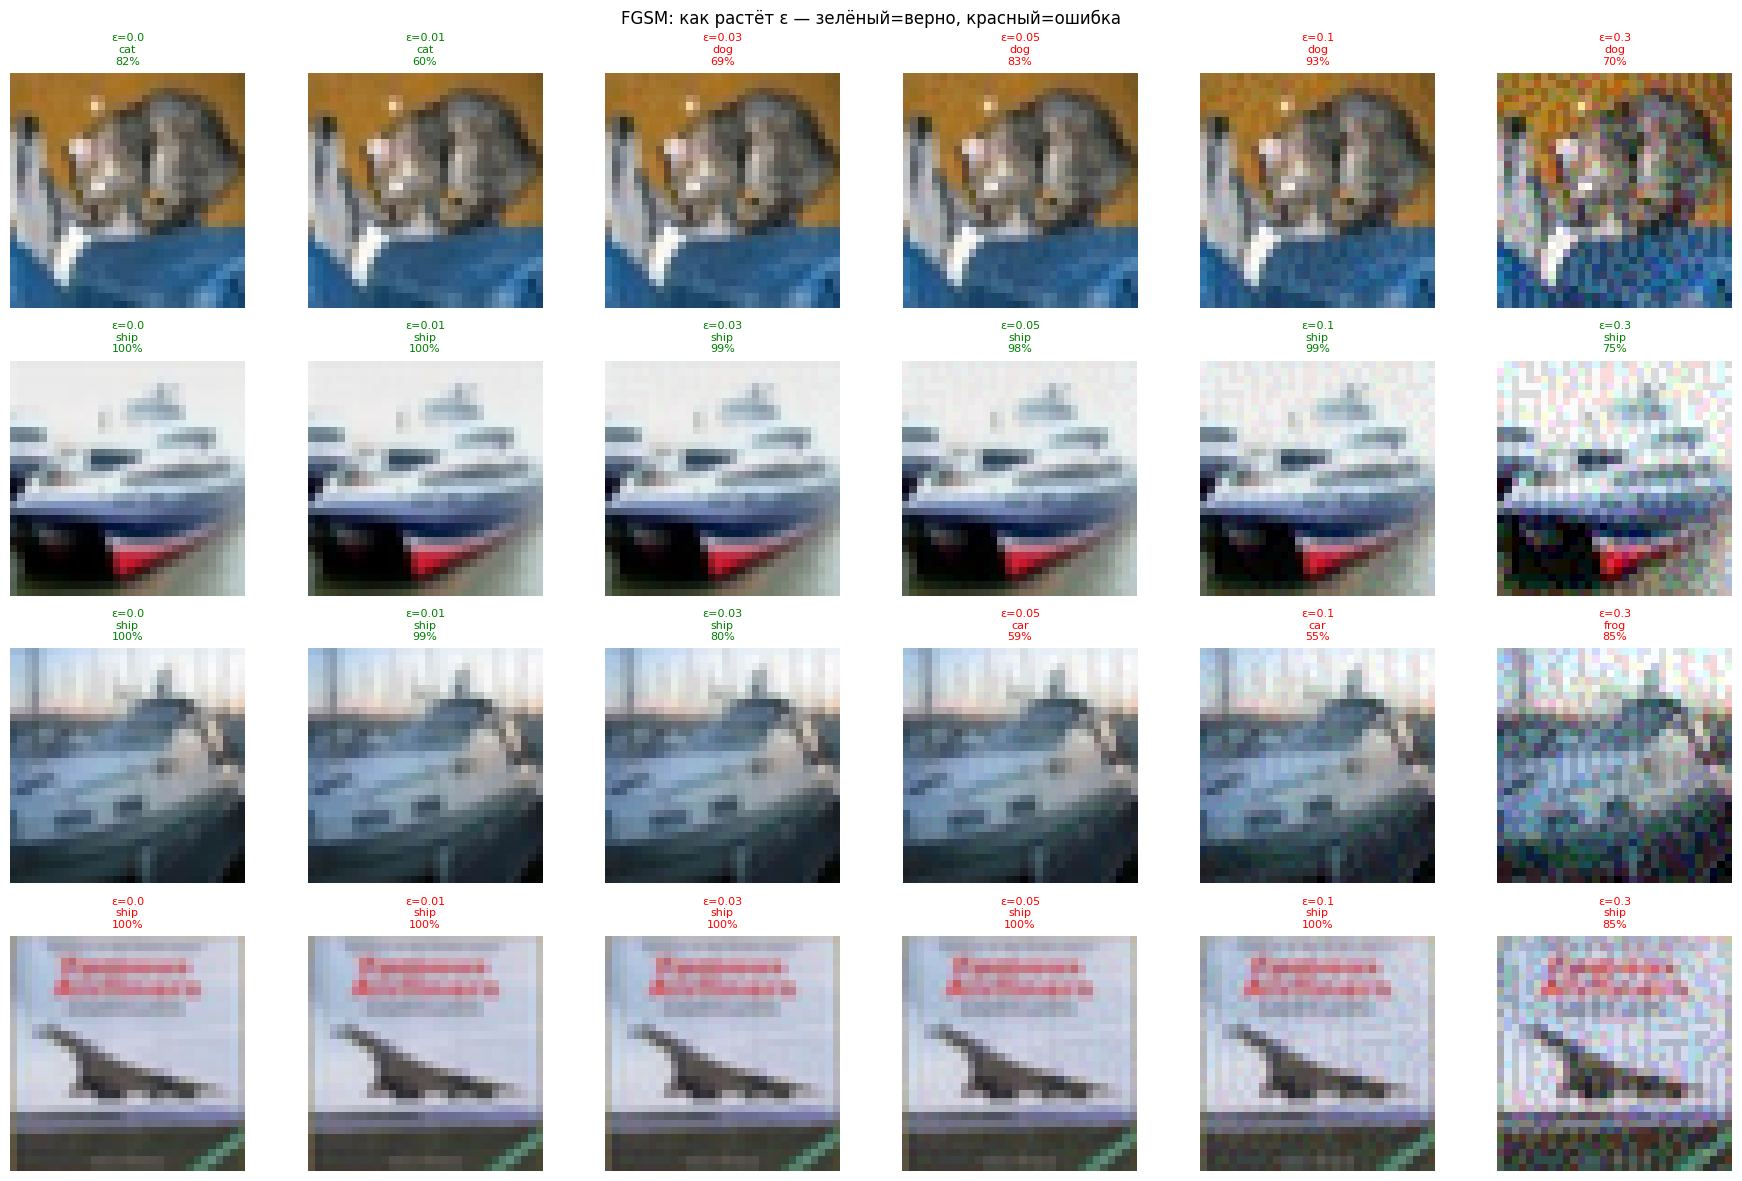

In [5]:
# image diffrents with different epsilon!

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../')

from src.model import CNN
from src.attacks import fgsm_attack

device = torch.device('cpu')
model = CNN().to(device)
model.load_state_dict(torch.load('../results/model.pth', map_location=device))
model.eval()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=False,
transform=transform)
classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

def denorm(tensor):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    return (tensor.squeeze(0).cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy()

# Берём 4 разные картинки
indices = [0, 1, 2, 3]
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1, 0.3]

fig, axes = plt.subplots(len(indices), len(epsilons), figsize=(18, 12))

for row, idx in enumerate(indices):
    image, label = testset[idx]
    image = image.unsqueeze(0).to(device)
    label_tensor = torch.tensor([label]).to(device)

    for col, eps in enumerate(epsilons):
        if eps == 0.0:
            img = image
        else:
            img = fgsm_attack(model, image, label_tensor, epsilon=eps)

        with torch.no_grad():
            logits = model(img)
            probs  = torch.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)

        vis = denorm(img)
        axes[row][col].imshow(vis)
        axes[row][col].axis('off')

        correct = classes[pred.item()] == classes[label]
        color = 'green' if correct else 'red'
        axes[row][col].set_title(
            f'ε={eps}\n{classes[pred.item()]}\n{conf.item()*100:.0f}%',
            fontsize=8, color=color
        )

        # подпись строки — оригинальный класс
        if col == 0:
            axes[row][col].set_ylabel(f'GT: {classes[label]}', fontsize=9)

plt.suptitle('FGSM: как растёт ε — зелёный=верно, красный=ошибка', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/fgsm_epsilon_grid.png', dpi=150)
plt.show()

In [1]:
import os
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'